**Evidence-coverage report: behavioral + MEC/LEC/HPC diagnostic slice.**
This report evaluates the current report-backed evidence for TEM-style
structural memory by inspecting behavioural prediction, MEC/g structural
states, LEC/x content states, and HPC/p binding-related states. The current
evidence supports a diagnostic slice of the g/x/p factorisation, while
training dynamics, formal remapping/generalisation, ablations, shuffle
baselines, and explicit retrieval-pathway analyses remain open.


| Field              | Value                               |
| ------------------ | ----------------------------------- |
| Model family       | TEM v1, TEM v2, EHP v1, EHP v2      |
| Task               | Arena (next-observation prediction) |
| Created            | 2026-06-02T07:29:25Z                |
| Device / precision | CPU (diagnostic regime)             |
| Seed               | Not recorded in provenance          |


Available reports and figures:


In [56]:
from ehc_sn.reporting import open_report
from IPython.display import Image, Markdown, display

# Report paths
TEM_V1_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v1/arena_n1"
TEM_V2_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v2/arena_n1"

# Load reports
tem_v1_report = open_report(TEM_V1_REPORT_PATH)
tem_v2_report = open_report(TEM_V2_REPORT_PATH)

# Display report summaries for tem_v1
print("TEM v1 report summary:")
print(f"  - report:   {tem_v1_report.root}")
print(f"  - metrics:  {tem_v1_report.summary()['metric_count']}")
print(f"  - metrics:  {tem_v2_report.summary()['metric_count']}")

# Display report summaries for tem_v1
print("TEM v2 report summary:")
print(f"  - report:   {tem_v2_report.root}")
print(f"  - figures:  {tem_v1_report.summary()['figure_count']}")
print(f"  - figures:  {tem_v2_report.summary()['figure_count']}")

TEM v1 report summary:
  - report:   /home/borja/ehc-sn/artifacts/reports/tem_v1/arena_n1
  - metrics:  2
  - metrics:  2
TEM v2 report summary:
  - report:   /home/borja/ehc-sn/artifacts/reports/tem_v2/arena_n1
  - figures:  16
  - figures:  16


# Scientific Question

**Does the model learn a reusable structural representation of
environment topology, separable from sensory content, in the sense
described by the Tolman–Eichenbaum Machine (Whittington et al., 2020)?**

We inspect four internal pathways to evaluate evidence at
four levels:

| Level                        | Evidence required                                              |
| ---------------------------- | -------------------------------------------------------------- |
| **Behavioral**               | Does the model solve the next-observation prediction task?     |
| **Predictive**               | Are predictions topologically meaningful (better on revisits)? |
| **Latent geometry**          | Does MEC `g` encode structure, LEC `x` encode content?         |
| **Neural-style diagnostics** | Do units show place-like, grid-like, or landmark-like tuning?  |


# Task and Benchmark — Arena Replay

Arena is a structural-navigation task where an agent navigates a 2-D grid
dungeon topology. At each step the agent occupies one passable cell and
observes a categorical **observation ID** (a unique integer per cell).
The agent can move in four cardinal directions (↑↓←→) or stop (idle action).

**Navigation**: An agent starts at a random location and navigates the
environment for a fixed number of steps. The trajectory is randomly generated
and used to produce a sequence of observations and actions.

**Prediction task:** At each step $t$, the model receives the previous
observation ID and the action taken, and must predict the observation ID
at $t+1$.

**Revisit definition:** A **revisit** occurs when the agent occupies a cell
it has already visited earlier in the same episode. High accuracy on revisit
steps is **consistent with** structural memory, but does not by itself establish
grid-like or hippocampal-like representations.

Note that the model does not perform an action, but receives the action taken by
the agent as input. This design choice allows us to evaluate the model's ability
to predict the next observation ID based on its internal representation of the
environment and the agent's actions, without confounding the results with the
model's own action selection process.


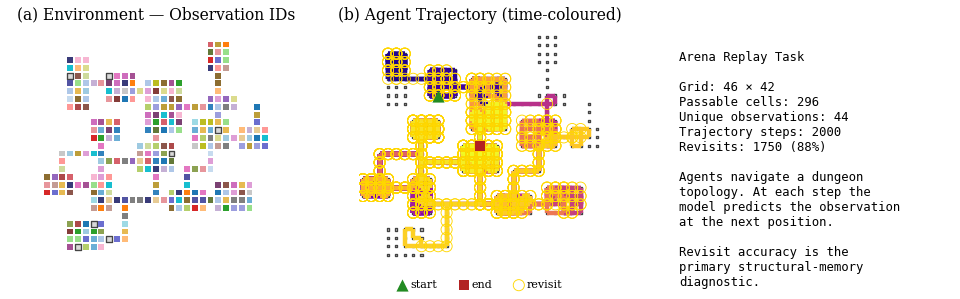

In [57]:
# Arena Task Overview (paradigm context; same dataset for both models)
overview_entry = tem_v1_report.figure_entry("arena_task_layout", preferred_format="png")
if overview_entry:
    abs_path = tem_v1_report.root / overview_entry.path
    display(Image(filename=str(abs_path)))
else:
    print("arena_task_layout not available.")

> Figure 1: Example episode in the Arena task. Panel (a) shows the dungeon topology, with free cells coloured by their unique observation ID. Panel (b) shows the agent's trajectory through the environment, coloured by time. Revisits are highlighted with yellow circles, indicating when the agent returns to a previously visited cell.


# Model Internals Inspected

The TEM architecture separates structural knowledge (MEC-like) from sensory
content (LEC-like) via a conjunctive hippocampal (HPC) binding. This report
inspects the following internal variables and pathways:

| System    | Scientific role                    | Report-facing name            |
| --------- | ---------------------------------- | ----------------------------- |
| LEC (`x`) | Sensory-content state              | LEC content-state activity    |
| MEC (`g`) | Structural state, path integration | MEC structural state          |
| HPC (`p`) | Structure-content binding          | HPC binding/place-like state  |
| Output    | Behavioral prediction (3 pathways) | Prediction argmax per pathway |
| Target    | Ground-truth observation sequence  | Target observation IDs        |


# Behavioral Performance

The primary metric for Arena-Struct is `accuracy_revisit` — accuracy on
steps where the agent returns to a previously visited cell. The secondary
metric is `accuracy_all` — overall next-observation prediction accuracy.

**Chance baseline:** Uniform random guessing over 45 observation classes
yields $1/45 \approx 0.022$.


## Model comparison

The code cell below prints the scalar metrics from their respective ReportRun
artifacts. It reports `accuracy_all`, `accuracy_revisit`, and summary metadata.


In [58]:
# Display metrics from both ReportRuns
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    if report is None:
        continue
    metrics = report.metrics()
    print(f"\n{label}:")
    for m in metrics:
        hb = " (higher is better)" if m.higher_is_better else ""
        print(f"  {m.metric:<30s} {m.value:<8.3f} {m.unit or '—':<10s} {hb}")

print()
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    if report is None:
        continue
    s = report.summary()
    print(
        f"{label}: {s['model_family']}, {s['metric_count']} metrics, "
        f"{s['figure_count']} figures"
    )


TEM v1:
  accuracy_all                   1.000    ratio       (higher is better)
  accuracy_revisit               1.000    ratio       (higher is better)

TEM v2:
  accuracy_all                   1.000    ratio       (higher is better)
  accuracy_revisit               1.000    ratio       (higher is better)

TEM v1: tem-v1, 2 metrics, 16 figures
TEM v2: tem-v2, 2 metrics, 16 figures


> **What to look for:** Both models should show near-ceiling accuracy on
> this 4-case diagnostic slice. Differences between v1 and v2 on this
> small slice should be checked against the evaluation configuration before
> being interpreted as a model-capability difference.


## Arena Prediction Overlays

Ground-truth observation sequence (`gt`) vs. three prediction pathways:

| Prediction pathway | Scientific role                                       |
| ------------------ | ----------------------------------------------------- |
| Inference          | Overall prediction, combining all sources of evidence |
| Retrieved          | Prediction based on retrieved memory traces           |
| Ancestral          | Prediction based on structural prior (MEC-like) alone |

Below is the first case's arena_prediction_overlay figure from each ReportRun.


TEM v1 — arena_prediction_overlay (case=arena_n1)


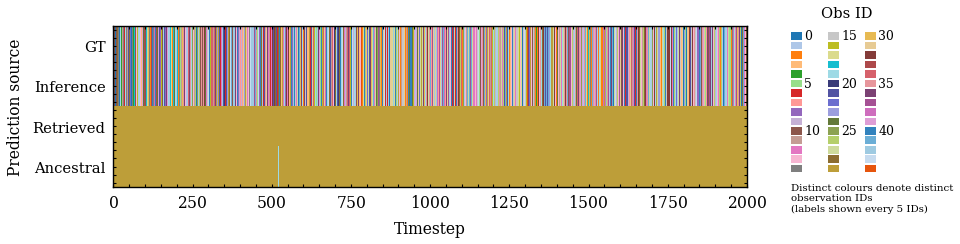

TEM v2 — arena_prediction_overlay (case=arena_n1)


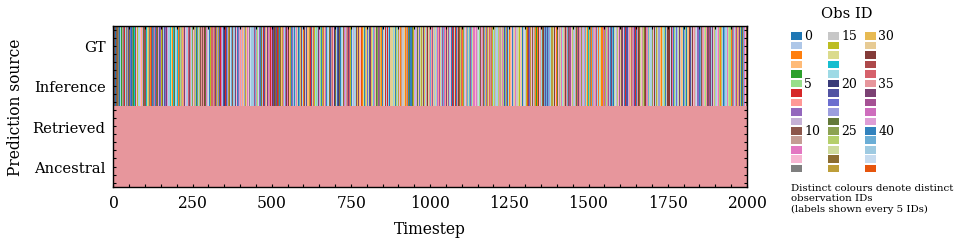

In [59]:
# --- Arena prediction overlay: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("arena_prediction_overlay", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: arena_prediction_overlay not available.")

> Figure 2: Prediction overlays for the first case in each ReportRun. Each sequence shows the predicted observation ID (colour) for each pathway (inference, retrieved, ancestral) compared to the ground-truth (GT) observation ID at each step. The pattern of mismatches across pathways can provide insight into the model's reliance on structural vs. content information for prediction.


# LEC / x Sensory-Content

The TEM implementation includes an explicit LEC stream that processes
observation embeddings before projection into HPC. In the
Tolman–Eichenbaum interpretation, this stream corresponds to the sensory/
content state $x$.

This section evaluates the LEC content stream in two ways. First, the
content-filtering diagnostic figure shows LEC content-state and
filtered-state per-unit activations across frequency bands, plus the
learned retention and input-mixing gate values annotated inside each
band label. Second, the content-vs-location contrast asks whether
LEC activity is organised more by sensory identity than by arena location,
and compares that organization against MEC/g and HPC/p.

Together, these figures test whether LEC acts as a content-state stream
rather than another spatial-map diagnostic.

### Variables inspected

Inputs inspected:

- `diagnostic/lec/sensory_code`: raw sensory code $c$ per frequency band
- `diagnostic/lec/filtered`: EMA-filtered LEC state per frequency band
- `lec_alpha_sigmoid`: learned retention gate $\alpha_f$ per band
- `lec_w_f_sigmoid`: learned input-mixing gate $\sigma(w_f)$ per band
- `t`: trajectory step (horizontal axis in activation panels)
- `f_k`: frequency band index (vertical grouping)
- `observation_id`, `location_id`: environment annotations used for RSA grouping

Typical shapes:

- Each band array: [time, n_units_per_band]
- Stacked matrix: [n_rows, time] after concatenating bands with NaN separators
- Plotted value: raw channel activation, not a decoded prediction.


## Content-state filtering

This is a **model-internal activation-flow diagnostic** for the sensory content stream — not a biological firing-rate raster. This section shows whether LEC units exhibit frequency-dependent activation structure and whether the filtering mechanism suppresses or enhances specific activation dimensions. It addresses whether the LEC stream shows content-related structure rather than undifferentiated activity.

**What to look for:** Inspect three properties across the transformation cascade. First, whether the sensory code (panel a) shows differentiated structure across frequency bands — different activation profiles across bands indicate that the sensory stream is not collapsed into a uniform code. Second, whether the EMA-filtered state (panel b) preserves or modifies those patterns relative to panel a — the $\alpha_f$ values annotate retention strength per band. Third, whether the final LEC cells (panel c) amplify or attenuate specific bands via $\sigma(w_f)$ — bands with $\sigma(w_f) \approx 0$ are effectively silenced. Pay attention to whether the learned gate parameters ($\alpha_f$, $\sigma(w_f)$) have moved from their initialization values, which would indicate training-shaped filtering.


TEM v1 — lec_content_filtering (case=arena_n1)


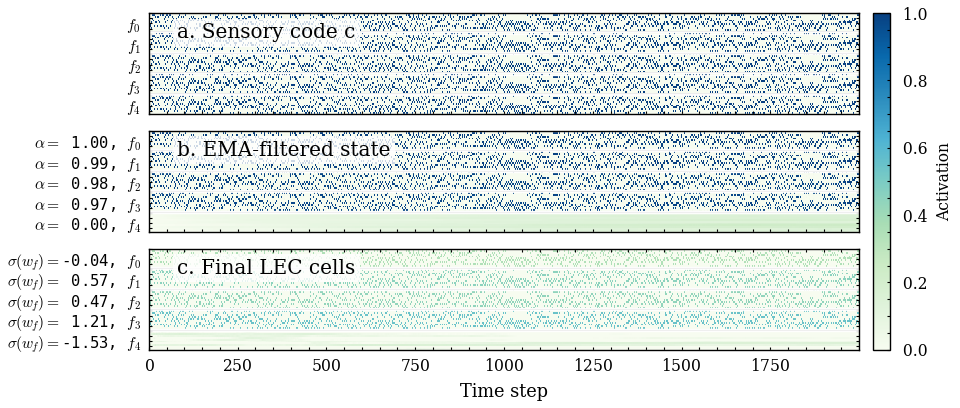

TEM v2 — lec_content_filtering (case=arena_n1)


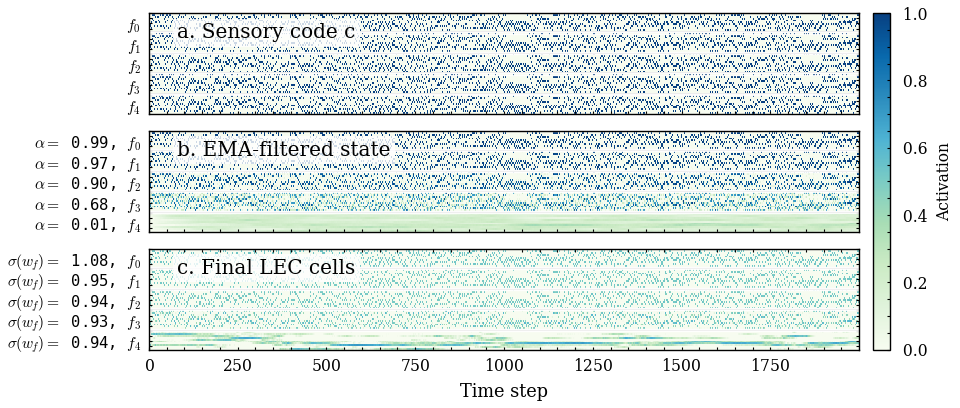

In [60]:
# --- LEC content filtering: first case from TEM v1 ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("lec_content_filtering", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: lec_content_filtering not available.")

> Figure 3: Content-filtering diagnostic figure for the LEC stream. Panel (a) shows the content-state activations per unit, grouped by frequency band. Panel (b) shows the filtered-state activations in the same row order. Panel (c) shows the filter effect, highlighting which activation dimensions are suppressed or enhanced by the frequency-dependent filtering. The learned gate parameters ($\alpha_f$, $w_f$) are annotated in the band labels on the left margin.


**Interpretation guide.**  
When reading Figure 3, consider what each panel reveals about the sensory stream. Panel A shows the raw sensory code entering LEC. Different activation patterns across frequency bands would indicate that sensory input is decomposed into distinguishable frequency components, rather than collapsed into a uniform representation. If all bands look identical, the sensory stream may lack frequency-specific structure.

Panel B shows the EMA-filtered state. Compare it visually to Panel A: dimensions that are suppressed or enhanced relative to the sensory code indicate where the filter is active. The $\alpha_f$ values in the y-axis labels quantify per-band retention — high $\alpha_f$ means the filter integrates over a longer temporal window; low $\alpha_f$ means it tracks recent input more closely. If $\alpha_f$ values are all near their initialization default, the filtering mechanism may not have been shaped by training.

Panel C shows the final LEC cells after mean-subtraction, ReLU, L2 normalisation, and $\sigma(w_f)$ scaling. Bands with $\sigma(w_f) \approx 0$ are attenuated before downstream binding; bands with $\sigma(w_f) \approx 1$ pass through at full strength. A distributed pattern across many bands suggests combinatorial sensory coding; a sparse pattern with only a few dominant bands suggests stronger channel specialisation.

The key question is not whether LEC looks like a biological LEC recording. The question is whether the sensory stream contains structured, non-identical frequency responses that downstream modules (MEC, HPC) could use for content binding.


## Content vs. location organisation across TEM streams

A TEM-style factorisation predicts a relative dissociation: LEC should
show stronger content organisation, MEC stronger location organisation,
and HPC may combine both. The figure reports the measured values.

Definitions:

- _content effect_ = mean similarity(same observation) − mean similarity(different observation)
- _location effect_ = mean similarity(same location) − mean similarity(different location)

**What to look for:** Inspect whether LEC states are more similar when the
same observation is present (content effect) than when the location is the
same (location effect). The reverse pattern should be checked for MEC.
For HPC, consider whether both effects are present at comparable magnitude
or whether one dominates. The relative balance across systems is the key
test of the TEM factorisation.


TEM v1 — lec_content_structure_rsa (case=arena_n1)


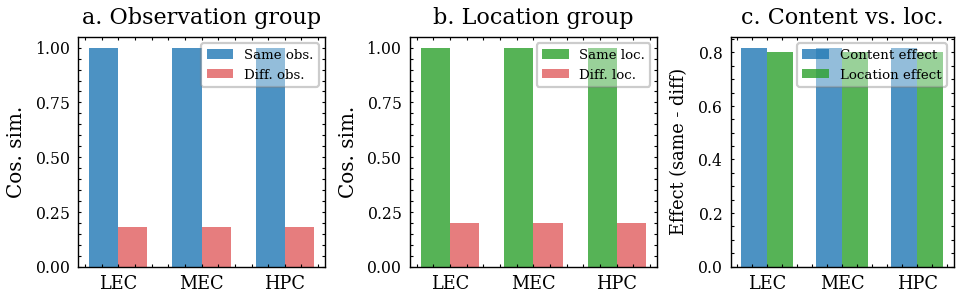

TEM v2 — lec_content_structure_rsa (case=arena_n1)


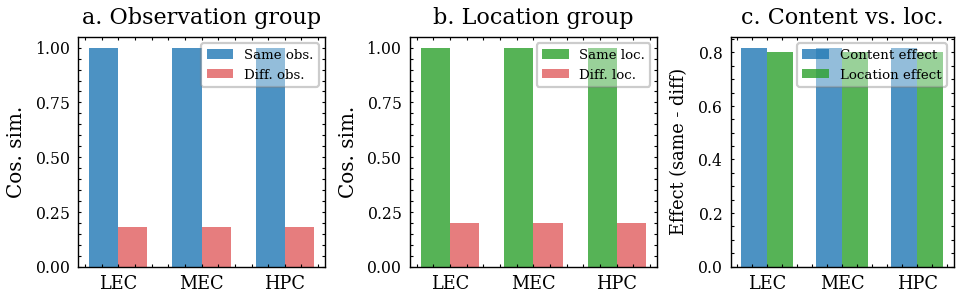

In [61]:
# --- LEC content structure RSA: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("lec_content_structure_rsa", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: lec_content_structure_rsa not available.")

> Figure 4: Content vs. location organization across TEM streams. Panel (a)
> shows the LEC similarity split by same/different observation, Panel (b) shows
> the MEC similarity split by same/different location, and Panel C plots the
> content effect vs location effect for all three streams (LEC, MEC, HPC).
> The relative magnitudes of these effects across streams can provide evidence
> for the functional roles of each stream in encoding content and structure.


**Interpretation guide.**  
Figure 4 tests the TEM factorisation directly. Panel A shows whether LEC states are more similar to each other when the same observation is present (blue bar) versus when different observations are present (red bar). A positive gap (blue > red) would indicate that LEC is organised by sensory content. Panel B shows the same comparison for location: green bars are mean similarity of states at the same arena location, red bars at different locations. A positive gap (green > red) would indicate organisation by spatial position.

Panel C summarises the dissociation as content effect and location effect per system. The TEM prediction is that LEC should show a stronger content effect than location effect, MEC the reverse, and HPC may show both. If all three systems show the same pattern, the predicted factorisation is not supported.

The main limitation to consider is that the RSA analysis uses cosine similarity between raw state vectors. This measures global representational overlap, not whether individual units are selectively tuned to content or structure. A system could appear to carry both content and location information in this metric even if individual units are highly specialised.


# MEC / g Structural-Stream

The TEM implementation includes an explicit MEC stream that performs path
integration and encodes relational/structural state before projection into
HPC. In the Tolman–Eichenbaum interpretation, this stream corresponds to
the structural state $g$.

This section evaluates the MEC structural stream in two ways. First, the
gridness metrics figure shows quantitative gridness scores and grid spacing
per frequency band, with representative autocorrelograms for top-scoring
cells. Second, the population autocorrelogram mosaic shows the full
distribution of spatial autocorrelation structure across all MEC cells,
ordered by gridness score.

Together, these figures test whether MEC encodes environment topology with
grid-like spatial periodicity — the signature of a reusable structural
representation — rather than producing an unstructured state vector.

### Variables inspected

Inputs inspected:

- `diagnostic/mec/location_mean`: per-frequency MEC cell activations,
  spatially binned into arena rate maps
- `location_id`: arena position annotation used for spatial binning
- `f_k`: frequency band index
- `t`: trajectory step (used to accumulate occupancy before spatial binning)

Typical shapes:

- Each frequency band: [n_cells, n_locations] after spatial binning
- Plotted value: spatially-binned mean activation (rate map), not raw
  temporal activation.


## Gridness metrics

This figure shows quantitative gridness scores and grid spacing per
frequency band, with representative rate-map and autocorrelogram examples
for top-gridness cells. It addresses whether MEC/g states exhibit
six-fold spatial periodicity — the hallmark of grid-like representations.

**What to look for:** Inspect three properties. First, whether gridness
scores in any frequency band consistently exceed zero — positive gridness
indicates six-fold rotational symmetry in the rate-map autocorrelogram.
Second, whether the top-gridness example cells show clear periodic
autocorrelograms, or whether high scores reflect artefactual correlations.
Third, whether grid spacing is consistent within each band and differs
between bands, which would suggest multiple spatial scales.


TEM v1 — mec_grid_metrics (case=arena_n1)


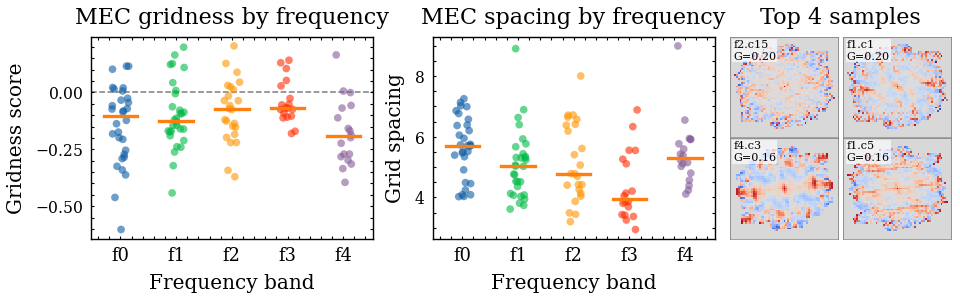


TEM v2 — mec_grid_metrics (case=arena_n1)


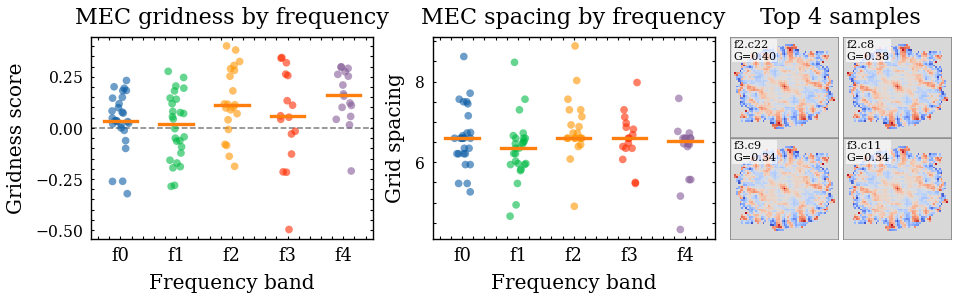

In [62]:
# --- MEC quantitative gridness metrics: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("mec_grid_metrics", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mec_grid_metrics not available.")
    print()

> Figure 5: Quantitative gridness metrics for the MEC stream. Panel (a) shows
> gridness score distributions per frequency band. Panel (b) shows estimated
> grid spacing per frequency band. Panel (c) shows rate maps and
> autocorrelograms for the top-gridness cells in each band. The figure
> addresses whether MEC/g states encode environment topology with grid-like
> structure.


**Interpretation guide.**  
When reading Figure 5, consider what each panel reveals about the structural
stream. Panel (a) shows the distribution of gridness scores per frequency
band. Scores consistently above zero would indicate that cells in that band
exhibit six-fold rotational symmetry — consistent with hexagonal
periodicity. Negative or near-zero scores would indicate that rate maps
lack periodic spatial structure.

Panel (b) shows estimated grid spacing per band. If spacing is consistent
within a band and differs across bands, this would suggest that different
frequency bands encode spatial periodicity at different scales — a
multi-scale grid code. If spacing is uniform across all bands, the bands
may not be functionally differentiated.

Panel (c) shows the spatial rate maps and autocorrelograms for the
top-gridness cells. A cell with a periodic rate map would show a central
peak surrounded by six satellite peaks at approximately 60° intervals in
its autocorrelogram. If high-gridness cells show noisy or unstructured
autocorrelograms, the gridness metric may be capturing artefactual
correlations rather than genuine periodicity.

The main limitation is that these gridness scores are descriptive without a
shuffle or occupancy-matched null distribution. Scores above zero are
consistent with spatial periodicity but do not by themselves establish that
the model has learned grid-like representations in the biological sense.


## Population autocorrelogram mosaic

This figure shows the full population of rate-map autocorrelograms, ordered
by descending gridness score per frequency band. It complements the
quantitative gridness metrics by making spatial structure — or its absence —
visible across all MEC cells, not just the top-scoring examples.

**What to look for:** Inspect the range of autocorrelation structure across
the population. Cells near the top of each band should be checked for
visible six-fold symmetry. The transition from structured to unstructured
autocorrelograms across the population should be inspected for whether it
is gradual (consistent with a distributed code) or sharp (suggesting a
small subset of specialised cells). Compare across frequency bands: if one
band consistently produces more structured autocorrelograms than others,
that band may be the primary carrier of spatial periodicity.


TEM v1 — mec_autocorr_mosaic (case=arena_n1)


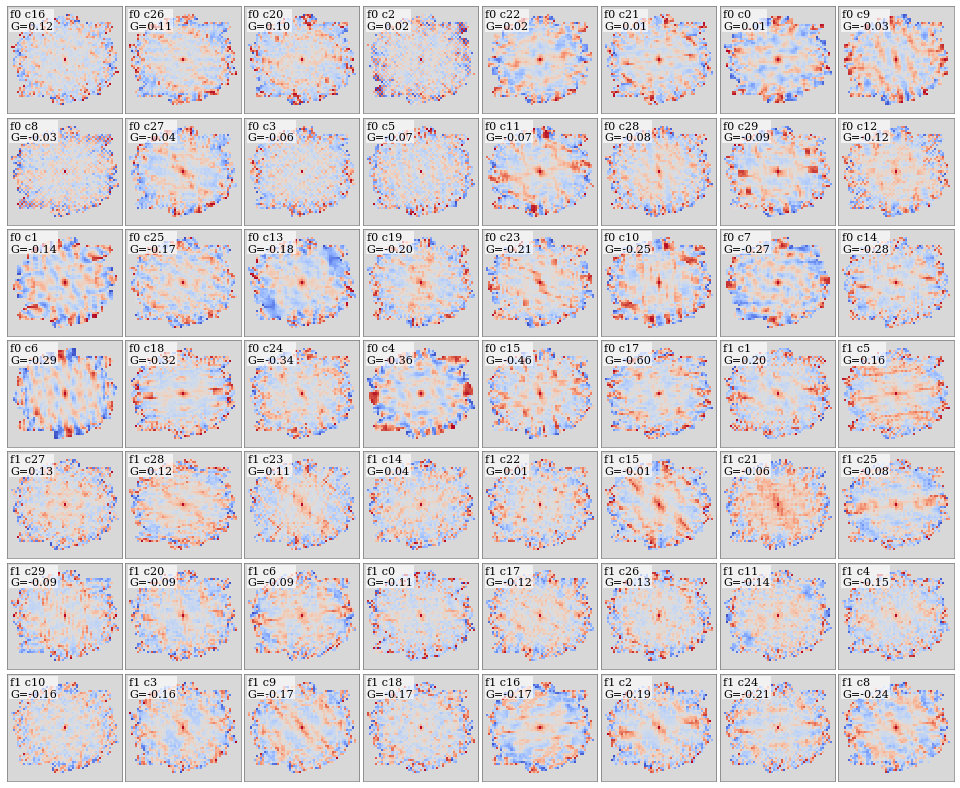

TEM v2 — mec_autocorr_mosaic (case=arena_n1)


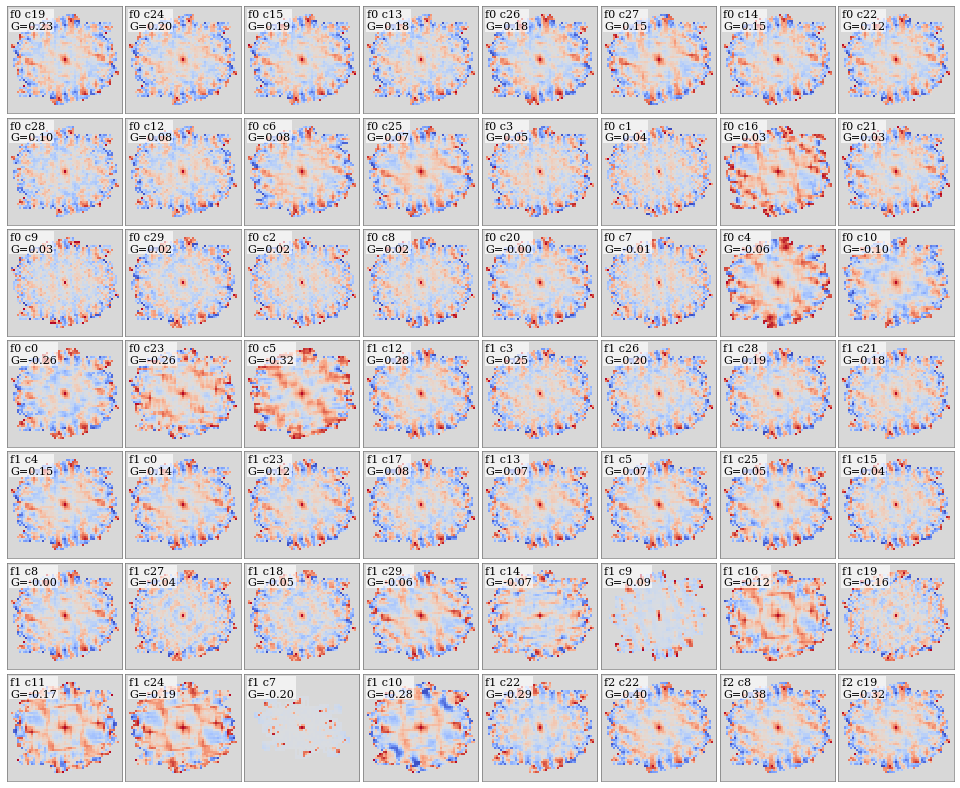

In [63]:
# --- MEC autocorrelogram mosaic: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("mec_autocorr_mosaic", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mec_autocorr_mosaic not available.")

> Figure 6: Population autocorrelogram mosaic for the MEC stream. Each tile
> is one cell's spatial autocorrelogram, ordered by descending gridness
> score within each frequency band. The mosaic complements the quantitative
> gridness metrics by showing the full population distribution of spatial
> autocorrelation structure.


**Interpretation guide.**  
When reading Figure 6, consider the population-level distribution of
autocorrelation structure. If grid-like periodicity is present, cells near
the top of each band would show visible six-fold symmetry in their
autocorrelograms — a central peak surrounded by six satellite peaks at
approximately 60° intervals. Cells near the bottom would show weaker or
absent periodic structure.

A smooth degradation from structured to unstructured autocorrelograms
across the population is consistent with a distributed grid code containing
a range of spatial tuning strengths. A sharp cutoff — where a few cells
show clear periodicity and the rest show noise — would suggest a small
specialised subpopulation rather than a distributed representation.

Comparing across frequency bands: if one band consistently produces more
structured autocorrelograms, that band may carry most of the model's
spatial periodicity. If no band shows visible periodicity, the gridness
scores may reflect artefactual correlations rather than genuine spatial
tuning.

The main limitation is the absence of a shuffle baseline. The mosaic is
descriptive and the reader should not over-interpret the presence of
periodic-looking autocorrelograms as definitive evidence of biological
grid-cell representations.


**Section conclusion — MEC/g.**  
This section provides the diagnostics needed to assess whether MEC/g states
exhibit grid-like spatial periodicity. Gridness scores can be compared
across frequency bands and between models; the presence of periodic
autocorrelograms can be inspected in the mosaic. The final conclusion should
be based on observed gridness values, the distribution across bands, and
comparison with a shuffle baseline (not yet available).


# HPC / p Place and Binding

The TEM implementation includes an explicit HPC stream that binds MEC
structural state (`g`) with LEC sensory content (`x`) into a conjunctive
episodic state. In the Tolman–Eichenbaum interpretation, this state
corresponds to the grounded hippocampal representation `p`.

This section evaluates the HPC conjunctive stream in two ways. First, the
place metrics figure shows quantitative spatial information scores,
field-center distributions, and representative rate-map examples for
top-scoring cells. Second, the population rate-map mosaic shows the full
distribution of spatial tuning across all HPC cells, ordered by spatial
information.

Together, these figures test whether HPC encodes place-like spatial
selectivity — the signature of a conjunctive representation that binds
structural position with sensory content — rather than producing an
unstructured or purely structural state vector.

### Variables inspected

Inputs inspected:

- `diagnostic/hpc/location_mean`: per-frequency HPC cell activations,
  spatially binned into arena rate maps
- `location_id`: arena position annotation used for spatial binning
- spatial information: per-cell measure of how concentrated firing is at
  specific locations
- `t`: trajectory step (used to accumulate occupancy before spatial binning)

Typical shapes:

- Each frequency band: [n_cells, n_locations] after spatial binning
- Plotted value: spatially-binned mean activation (rate map), not raw
  temporal activation.

## Place metrics

This figure shows quantitative spatial information scores, field-center
locations, and representative rate-map examples for top-scoring HPC cells.
It addresses whether HPC/p states exhibit localised spatial firing — the
hallmark of place-like conjunctive representations.

**What to look for:** Inspect three properties. First, whether spatial
information scores are shifted toward higher values, which would indicate
that many HPC cells have concentrated spatial firing fields. Second,
whether field centers are distributed across the full arena, which would
indicate population-level coverage of the environment. Third, whether the
top-scoring example cells show single localised firing fields — multi-field
or diffuse rate maps would indicate a different form of spatial tuning.

TEM v1 — hpc_place_metrics (case=arena_n1)


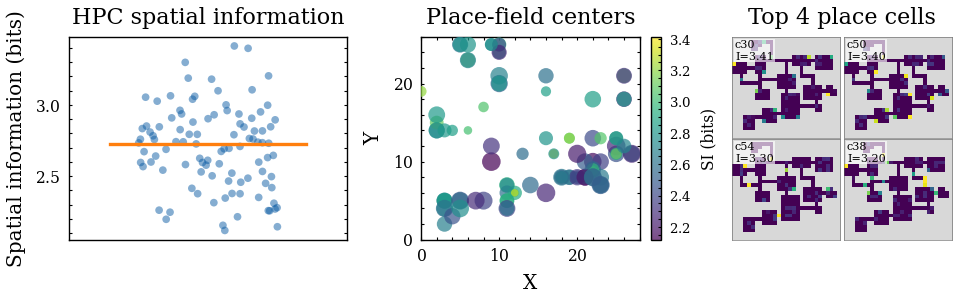


TEM v2 — hpc_place_metrics (case=arena_n1)


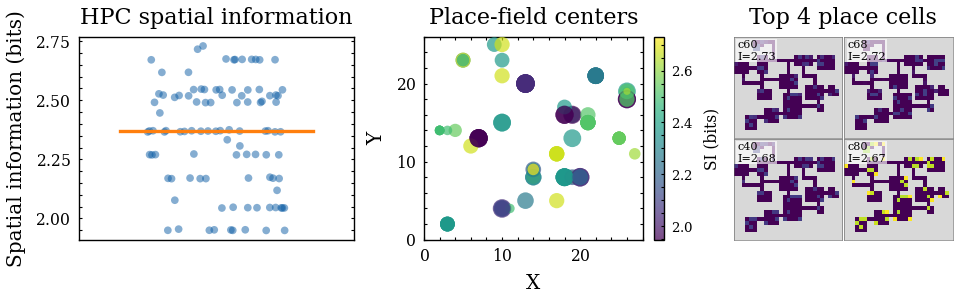

In [64]:
# --- HPC place metrics: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("hpc_place_metrics", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: hpc_place_metrics not available.")
    print()

> Figure 7: Place metrics for the HPC stream. Panel (a) shows the spatial
> information (SI) distribution across HPC cells. Panel (b) shows
> field-center locations over the arena. Panel (c) shows rate-map examples
> for the top-scoring cells (2×2 mosaic). The figure addresses whether
> HPC/p states exhibit place-like spatial selectivity.

**Interpretation guide.**  
When reading Figure 7, consider what each panel reveals about the HPC
conjunctive state. Panel (a) shows the distribution of spatial information
(SI) scores across HPC cells — higher SI indicates that a cell's firing is
more concentrated at specific locations. A distribution shifted toward
higher values would indicate that many cells have place-like spatial
selectivity. A distribution clustered near zero would indicate that HPC
states are not spatially localised.

Panel (b) shows where each cell's preferred firing location falls in the
arena. Field centres distributed across the full arena would indicate that
the population collectively covers the environment. Clustering in specific
regions would suggest the representation is biased toward certain positions.

Panel (c) shows rate-map examples for the highest-SI cells. A single
localised firing field is the hallmark of a place-like representation;
multi-field or diffuse rate maps would indicate a different form of spatial
tuning.

The main limitation is the lack of a shuffle baseline for SI significance.
Additionally, place-like selectivity in `p` is consistent with the TEM
hypothesis but does not by itself establish conjunctive g-x binding, which
requires cross-stream decoding.

## Population rate-map mosaic

This figure shows the full population of rate maps, ordered by descending
spatial information. It complements the place metrics by making spatial
tuning — or its absence — visible across all HPC cells, not just the
top-scoring examples.

**What to look for:** Inspect the range of rate-map structure across the
population. High-SI cells (top rows) should be checked for single-field
place-like patterns. The transition from structured to unstructured rate
maps should be inspected for whether it is gradual (consistent with a
distributed place code) or sharp (suggesting a small specialised
subpopulation). Note that ordering by SI creates a favourable view: the
population always looks better at the top than the bottom. The reader
should check whether even high-SI cells show multi-field or irregular
patterns, which would indicate that spatial tuning in HPC may differ from
canonical place-cell responses.

TEM v1 — hpc_rate_map_mosaic (case=arena_n1)


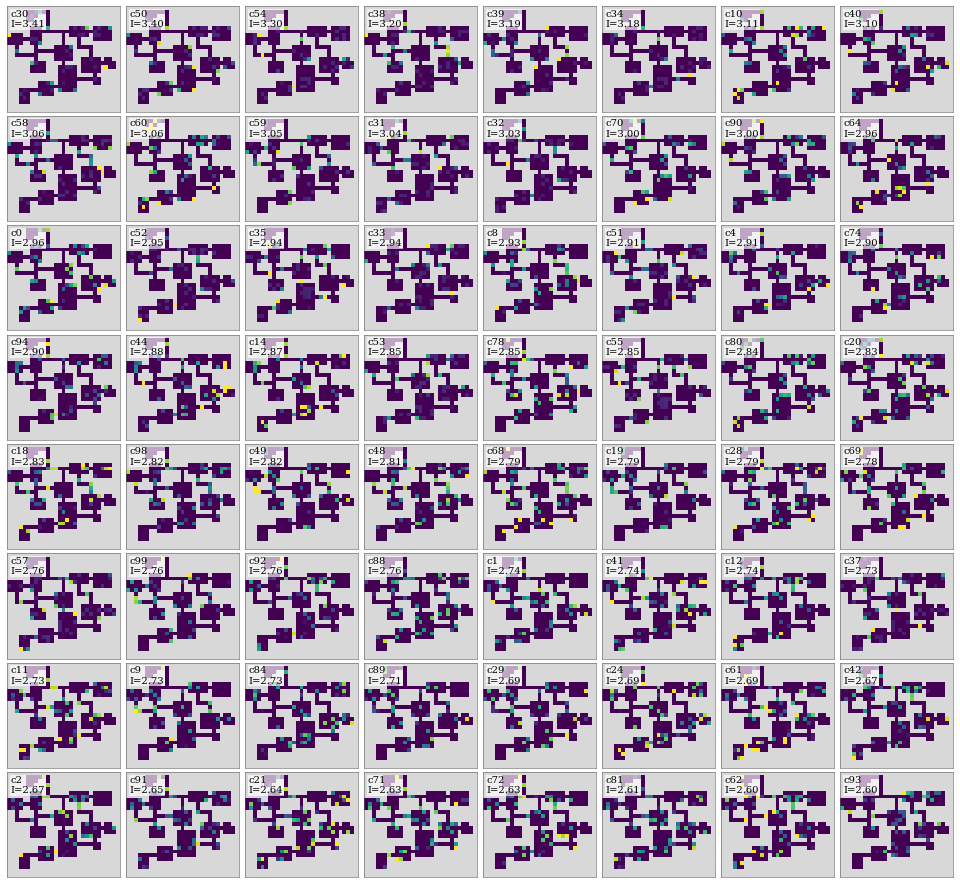


TEM v2 — hpc_rate_map_mosaic (case=arena_n1)


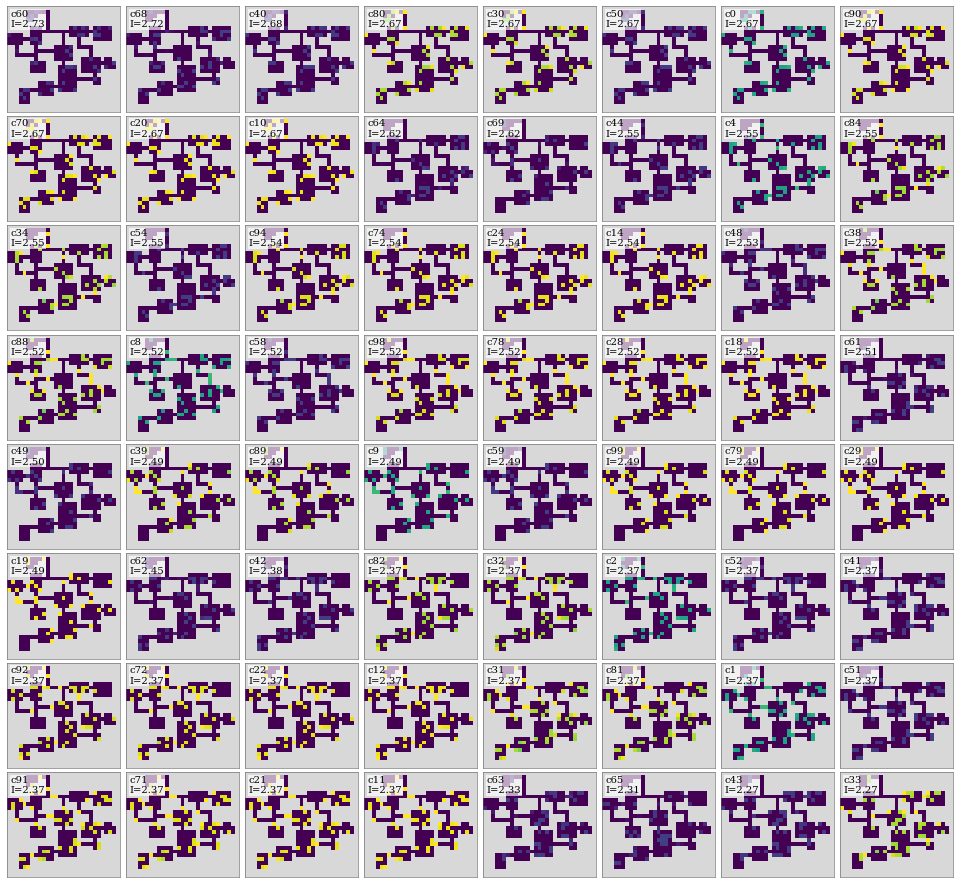

In [65]:
# --- HPC rate-map mosaic: first case from each ReportRun ---
for label, report in [("TEM v1", tem_v1_report), ("TEM v2", tem_v2_report)]:
    entry = report.figure_entry("hpc_rate_map_mosaic", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: hpc_rate_map_mosaic not available.")
    print()

> Figure 8: Population rate-map mosaic for the HPC stream. Each tile is one
> cell's spatially-binned rate map, ordered by descending spatial information.
> The mosaic complements the quantitative place metrics by showing the full
> population distribution of spatial tuning.

**Interpretation guide.**  
When reading Figure 8, consider the population-level distribution of rate-map
structure. If HPC is functioning as a conjunctive binding state, high-SI
cells would show clear single-field place-like patterns. Mid-range cells may
show broader or noisier fields. Low-SI cells may appear flat or unstructured.

A smooth gradient from structured to unstructured rate maps across the
population is consistent with a distributed place code. An abrupt transition
would suggest a small specialised subpopulation. If even high-SI cells show
multi-field or irregular patterns, the spatial tuning in HPC may differ from
canonical place-cell responses.

The main caveat is that the ordering by SI creates a favourable view: the
population always looks better at the top than the bottom. The transition
should be checked for whether it is gradual (expected for a distributed
code) or sharp (suggesting cherry-picking effects).

The main limitation is the absence of a shuffle baseline. The mosaic is
descriptive and the reader should not over-interpret place-like rate maps
as definitive evidence of biological place-cell representations.

**Section conclusion — HPC/p.**  
This section provides the diagnostics needed to assess whether HPC/p states
exhibit place-like spatial selectivity. Spatial information scores, field-center
distributions, and rate-map examples can be inspected to evaluate spatial tuning.
Full conjunctive binding of separable structural and content signals requires
cross-stream decoding or explicit conjunctivity diagnostics not yet implemented.


## 11. Evidence Gaps and Next Diagnostic Steps

This section consolidates all claims that are **not yet** evaluated or
report-backed. Unlike the evidence sections above, these are not stubs —
they are explicit blocker statements grouped by missing claim.

| Missing claim                  | Why it matters                                                                                | Current blocker                                  | Next artifact needed                                |
| ------------------------------ | --------------------------------------------------------------------------------------------- | ------------------------------------------------ | --------------------------------------------------- |
| **Training convergence**       | Establishes checkpoint credibility; distinguishes learned structure from overfit memorisation | Training logs not ingested                       | Train/val loss metric artifact                      |
| **Retrieval pathway**          | Tests whether memory lookup (not only prediction) is correct and interpretable                | Retrieval-specific traces not exposed in report  | Retrieval trace fields + retrieval accuracy metrics |
| **Remapping / generalisation** | Tests whether structural codes are reusable across environments                               | Only single small eval slice (4 cases) available | Cross-environment eval set with sensory remapping   |
| **Gridness significance**      | Controls false-positive grid-cell claims                                                      | No shuffle baseline implemented                  | Shuffled occupancy / rate-map null distribution     |
| **Place-field significance**   | Controls false-positive place-like claims                                                     | No shuffle baseline for spatial information      | Shuffled spatial information null distribution      |
| **Ablations**                  | Tests causal role of MEC/LEC/HPC modules                                                      | No ablation report runs exist                    | MEC/LEC/HPC lesion configs + eval runs              |

### Priority Order for Next Implementation

1. **Add shuffle baselines** for gridness and spatial information metrics
2. **Expose retrieval traces** and add retrieval-specific metrics
3. **Build cross-environment eval set** to test remapping / generalisation
4. **Run ablation studies** (MEC lesion, LEC lesion, no-memory variant)
5. **Ingest training logs** into ReportRun format (train/val loss curves)


## 12. Evidence Summary

| Claim                                           | Variable / pathway                    | Current status                              | Evidence status                                                        |
| ----------------------------------------------- | ------------------------------------- | ------------------------------------------- | ---------------------------------------------------------------------- |
| Solves Arena prediction task                    | Output predictions                    | ReportRun-backed (§6)                       | ✅ Available (n=4 diagnostic slice)                                    |
| Forms structural map                            | MEC / `g`                             | ReportRun-backed (§8)                       | ✅ Available — gridness metrics computed, descriptive                  |
| Encodes sensory content separate from structure | LEC / `x`                             | ReportRun-backed (§10)                      | ✅ Available — content-filtering and content-structure RSA diagnostics |
| Binds content to structure (conjunctive)        | HPC / `p`                             | Partially available (§9)                    | ⚠️ Place-like maps available; conjunctive binding not yet evaluated    |
| Retrieves stored structure-content associations | Memory / retrieval path               | Not yet main-report-ready (§11)             | ❌ Not yet evaluated — trace gap                                       |
| Generalises / remaps across environments        | Cross-env behaviour + representations | No cross-env eval set (§11)                 | ❌ Not yet evaluated                                                   |
| Gridness above shuffle                          | MEC / `g`                             | Gridness scores available, no baseline (§8) | ⚠️ Descriptive only — no shuffle baseline                              |
| Place-field above shuffle                       | HPC / `p`                             | SI scores available, no baseline (§9)       | ⚠️ Descriptive only — no shuffle baseline                              |
| Ablations confirm causal role                   | MEC / LEC / HPC                       | No ablation runs exist (§11)                | ❌ Not yet evaluated                                                   |

### Bottom Line

> Current evidence covers behavioral prediction on a bounded 4-case
> diagnostic slice, plus MEC/g structural diagnostics, LEC/x
> content-selectivity diagnostics, and HPC/p place-like diagnostics. The
> following are not yet addressed: (1) training convergence evidence,
> (2) explicit `g`/`x`/`p` disentanglement via remapping, (3) memory-retrieval
> diagnostics, (4) cross-environment generalisation, (5) shuffle baselines
> for gridness and spatial information, and (6) ablations.


## 13. Reproducibility

### Artifact Paths

| Artifact                    | Path                                                    |
| --------------------------- | ------------------------------------------------------- |
| TEM v1 ReportRun            | `artifacts/reports/tem_v1/arena_n1`                     |
| TEM v2 ReportRun            | `artifacts/reports/tem_v2/arena_n1`                     |
| TEM v1 eval artifacts       | `artifacts/evaluation/tem_v1/arena_n1`                  |
| TEM v2 eval artifacts       | `artifacts/evaluation/tem_v2/arena_n1`                  |
| TEM v1 checkpoint           | `checkpoints/tem-v1/eval-weights-only.pt` (step 10,000) |
| TEM v2 checkpoint           | `checkpoints/tem-v2/eval-weights-only.pt` (step 10,000) |
| TEM v1 model config         | `config/models/tem-v1-base.toml`                        |
| TEM v2 model config         | `config/models/tem-v2-base.toml`                        |
| TEM v1 report spec          | `config/reporting/tem_v1_arena_n4.toml`                 |
| TEM v2 report spec          | `config/reporting/tem_v2_arena_n4.toml`                 |
| Arena-Struct benchmark spec | `spec/spec-benchmark-suite.md` §6.1                     |

### Commands to Reproduce (current eval with LEC traces, n=1)

```bash
# Generate evaluation artifacts with all diagnostic traces (n=1)
python scripts/evaluation/run_eval.py \
    --model-family tem-v1 \
    --checkpoint checkpoints/tem-v1/eval-weights-only.pt \
    --config config/evaluation/tem-v1-arena.toml \
    --task arena \
    --provider-ref ehc_sn.tasks.arena.providers.ArenaReplayProvider \
    --provider-settings '{"dataset_path": "data/processed/arena/default/v1", "split": "test", "n_cases": 1}' \
    --regime-id arena_n1 --regime-kind diagnostic \
    --output artifacts/evaluation/tem_v1/arena_n1 --device cpu \
    --trace-keys '["diagnostic/mec/location_mean","diagnostic/hpc/location_mean","diagnostic/lec/cells","diagnostic/lec/filtered","world_step/observation","pred/observation_id/inference","pred/observation_id/retrieved","pred/observation_id/ancestral"]'

# Generate ReportRun from eval artifacts
python scripts/reporting/run_report.py \
    --config config/reporting/tem_v1_arena_n1.toml
```

### Known Reproducibility Gaps

| Gap                                 | Impact                                                                       |
| ----------------------------------- | ---------------------------------------------------------------------------- |
| Git commit SHA not recorded         | Cannot pin the exact code version                                            |
| Checkpoint SHA256 not recorded      | Cannot verify checkpoint integrity                                           |
| Random seed not recorded            | Cannot reproduce stochastic elements                                         |
| `diagnostic/lec/filtered` semantics | Not yet confirmed — may be frequency decomposition, not temporal persistence |
| LEC-to-HPC binding pathway          | Cross-stream decoding diagnostics not yet implemented                        |
| EHC v1 / EHC v2 checkpoints         | Not yet trained; structural-memory comparison incomplete                     |
